In [29]:
#%reload_ext autoreload
#%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import tqdm.notebook as tqdm
import h5py
import emcee

import holodeck as holo
from Nanograv_15_year_constraints import interpolate_lumdistmax_Nano_15, interpolate_h_ss_max_Nano_15, Detectable_Sources_Lumdist, Detectable_Strain, get_UL_vs_freq
from Nanograv_15_year_constraints import get_ss_GW_strain, get_bg_GW_strain
from holodeck import sams, host_relations, hardening
from holodeck import utils, plot, cosmo
from holodeck.constants import MSOL, YR, MPC, NWTG, SPLC, GYR
#from astropy import coordinates
holo.log.setLevel(holo.log.ERROR)

In [21]:
fp = dict([('psi0',-2.5),('m0',11.5),('mass_norm',8.3),('scatter',0.45),('tau',5.55),('gamma_inner',-0.75)])

In [33]:
fp.values()

dict_values([-2.5, 11.5, 8.3, 0.45, 5.55, -0.75])

Construct SAM

In [22]:
sam = sams.Semi_Analytic_Model(gsmf=sams.components.GSMF_Schechter(phi0=fp['psi0'],mchar0_log10=fp['m0']) , mmbulge= host_relations.MMBulge_Standard(mamp_log10=fp['mass_norm'],scatter_dex=fp['scatter']), shape=30)    

Construct Background and Single source GW strains

In [23]:
#Generate frequency bins according to simulation
OBS_DUR = 10.0 * YR    # duration of PTA observations in [sec], which determines the Fourier frequency basis
NUM_FREQS = 40  # number of frequency bins
fobs, fobs_edges = utils.pta_freqs(dur=OBS_DUR, num=NUM_FREQS)
NUM_REALS = 100  # Number of 'realizations' to generate
NUM_LOUDEST = 4  # Number of 'loudest' binaries to generate in each frequency bin
print(f"Number of frequency bins: {fobs.size}")
print(f"  between [{fobs[0]*YR:.2f}, {fobs[-1]*YR:.2f}] 1/yr")
print(f"          [{fobs[0]*1e9:.2f}, {fobs[-1]*1e9:.2f}] nHz")

Number of frequency bins: 40
  between [0.10, 4.00] 1/yr
          [3.17, 126.75] nHz


In [24]:
figdatafile = "../Nanograv_data/dist_ul_plot_data.npz"
npzfile = np.load(figdatafile)
xedges = npzfile['xedges']
d_eff_freq = npzfile['d_eff_freq']
d_worst_freq = npzfile['d_worst_freq']
d_best_freq = npzfile['d_best_freq']
dist_UL_freq = npzfile['dist_UL_freq']


In [25]:
#Generate frequency bins according to nanograv frequency bins
fobs = []
for i,v in enumerate(xedges[:-1]):
    fobs.append((v + xedges[i+1])/2)
NUM_FREQS = len(fobs)
NUM_REALS = 100   # Number of 'realizations' to generate
NUM_LOUDEST = 4  # Number of 'loudest' binaries to generate in each frequency bin
fobs = 10**np.array(fobs)
fobs_edges = 10**xedges

In [30]:
hc_ss, hc_bg, par_ss, par_bg = sam.gwb(fobs_edges, hard = hardening.Fixed_Time_2PL_SAM(sam=sam,time=fp['tau']*GYR,gamma_inner=fp['gamma_inner']), realize = NUM_REALS, loudest =NUM_LOUDEST, params=True)

14:37:41 ERROR : Warning, significant change in number-mass!  mass: 8.39e-01 ==> 1.86e+00 || change = 1.2232e+00 [sam.py:static_binary_density]


Define Luminosity Distance and Chirp Mass

In [10]:
h_ss = get_ss_GW_strain(fobs,fobs_edges,hc_ss)

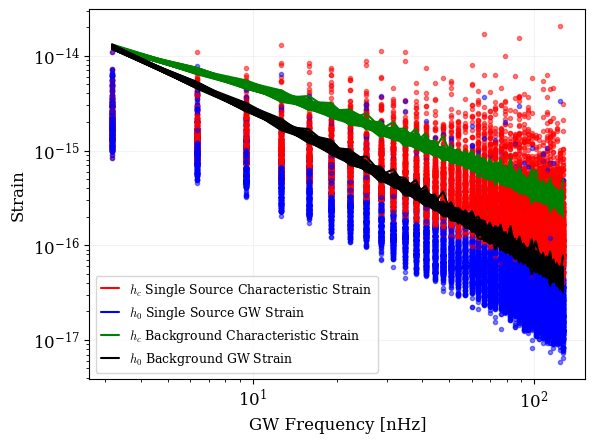

In [11]:
plt.rcParams.update({'font.size': 12})
for i in range(NUM_LOUDEST):
    plt.loglog(fobs*1e9, hc_ss[:,:,i], '.', alpha=0.5,color='red');#All realizations of the loudest pulsars for each frequency.
    plt.loglog(fobs*1e9, h_ss[:,:,i], '.', alpha=0.5,color='blue')
plt.loglog(fobs*1e9, hc_bg, color='green')
plt.loglog(fobs*1e9, get_bg_GW_strain(fobs,fobs_edges,hc_bg), color='black')
plt.loglog([],[],label='$h_c$ Single Source Characteristic Strain',color='red')
plt.loglog([],[],label='$h_0$ Single Source GW Strain',color='blue')
plt.loglog([],[],label='$h_c$ Background Characteristic Strain', color='green')
plt.loglog([],[],label='$h_0$ Background GW Strain',color='black')
plt.gca().set(ylabel='Strain', xlabel='GW Frequency [nHz]')
plt.legend(fontsize='9')
plt.savefig('BG+SS h_c')
plt.show()

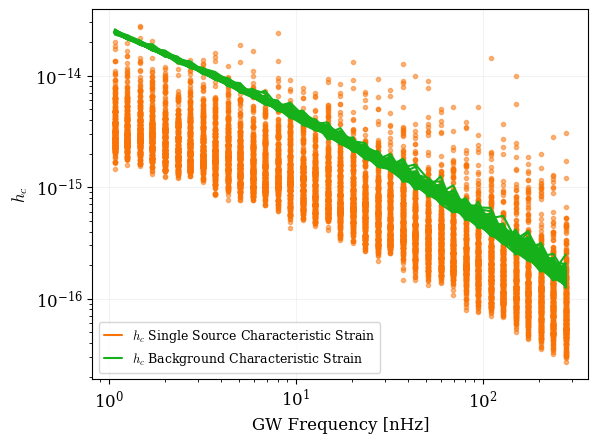

In [13]:
plt.rcParams.update({'font.size': 12})
for i in range(NUM_LOUDEST):
    plt.loglog(fobs*1e9, hc_ss[:,:,i], '.', alpha=0.5,color='xkcd:orange');#All realizations of the loudest pulsars for each frequency.
plt.loglog(fobs*1e9, hc_bg, color='xkcd:green')
plt.loglog([],[],label='$h_c$ Single Source Characteristic Strain',color='xkcd:orange')
plt.loglog([],[],label='$h_c$ Background Characteristic Strain', color='xkcd:green')
plt.gca().set(ylabel='$h_c$', xlabel='GW Frequency [nHz]')
plt.legend(fontsize='9')
plt.savefig('BG+SS h_c')
plt.show()

Luminosity Distance Calculator and Filter

In [64]:
Upper_boundsL = interpolate_lumdistmax_Nano_15(fobs,Chirp_Mass_ss)
fobsarr = np.tensordot(fobs,np.ones(NUM_REALS),axes=0)

In [65]:
with h5py.File('../data/15yr_quickCW_UL.h5', 'r') as f:
    samples_cold = f['samples_cold'][0,0::1,:]
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]

The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [69.78303829]


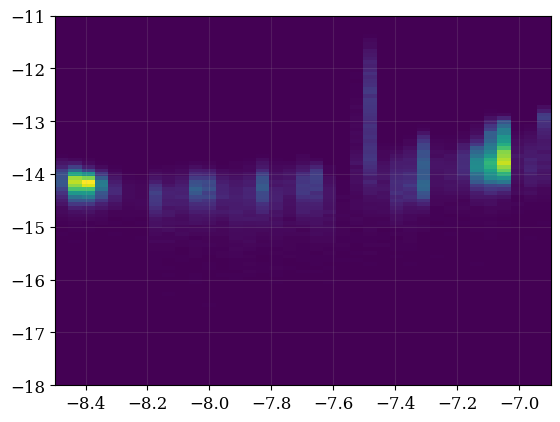

In [69]:
log10_fgws = samples_cold[0::1,3]
log10_hs = samples_cold[0::1,4]
UL_freq, UL_sigma, bincenters, xedges2 = get_UL_vs_freq(log10_fgws, log10_hs, [min(fobs),max(fobs)])
Upper_boundsh = interpolate_h_ss_max_Nano_15(fobs,xedges2,UL_freq)

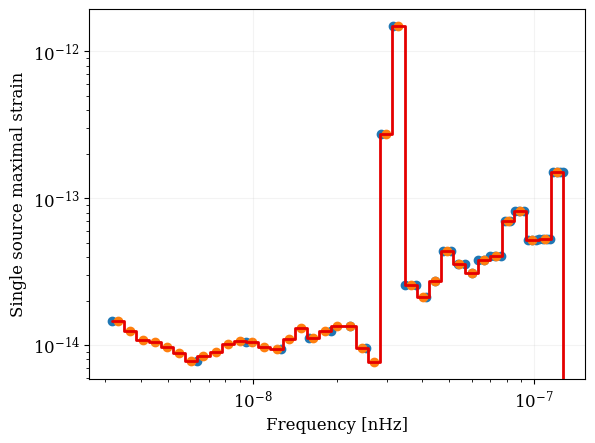

In [67]:
plt.step(10**xedges2, np.concatenate((UL_freq, [0.0,])), where='post',
             ls='-', lw=2, marker='', alpha=1.0, color="xkcd:red", label="15-year")
plt.scatter(fobs,Upper_boundsh)
plt.scatter(10**bincenters,UL_freq)
plt.ylabel('Single source maximal strain')
plt.xlabel('Frequency [nHz]')
plt.yscale('log')
plt.xscale('log')

In [71]:
np.shape(Upper_boundsh)

(40,)

In [67]:
FilteredStrain, FilteredFreqs, corresponding_upper_limit, realization_number, frequency_of_SMBHB = Detectable_Strain(fobs,h_ss,Upper_boundsh)

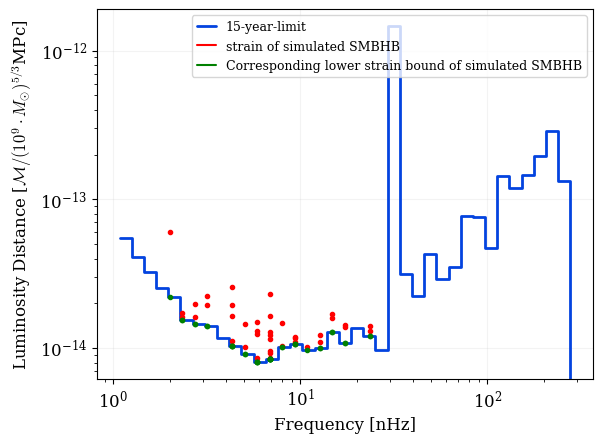

In [64]:
plt.xlabel('Frequency [nHz]')
plt.ylabel('Luminosity Distance [$\\mathcal{M}/(10^9 \\cdot M_{\\odot})^{5/3}$MPc]')
plt.step(10**9*10**xedges2, np.concatenate((UL_freq, [0.0,])), where='post',
             ls='-', lw=2, marker='', alpha=1.0, color="xkcd:blue", label="15-year-limit")
for i in np.arange(NUM_LOUDEST):
    plt.loglog(FilteredFreqs[:,:,i]*10**9,FilteredStrain[:,:,i],'.',color='red')
    plt.loglog(FilteredFreqs[:,:,i]*10**9,corresponding_upper_limit[:,:,i],'.',color='green')
plt.loglog([],[],label='strain of simulated SMBHB',color='red')
plt.loglog([],[],label='Corresponding lower strain bound of simulated SMBHB',color='green')
plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize='9')
#plt.savefig('Constrained Distance')
#print(f'{100*detectable/total}% of total realizations for the {NUM_LOUDEST} loudest binaries are detectable.')

SMBHBs that are louder than their background

In [69]:
c1, b1 = np.histogram(realization_number,bins=NUM_REALS)
success1 = 0
total1 = len(c1)
for i in c1:
    if i != 0:
        success1 += 1

In [70]:
c2, b2 = np.histogram(frequency_of_SMBHB,bins=NUM_FREQS)
success2 = 0
total2 = len(c2)
for i in c2:
    if i!= 0:
        success2 += 1

There is a 2.0% chance to detect a single source, with a mean number of detections of 0.02.


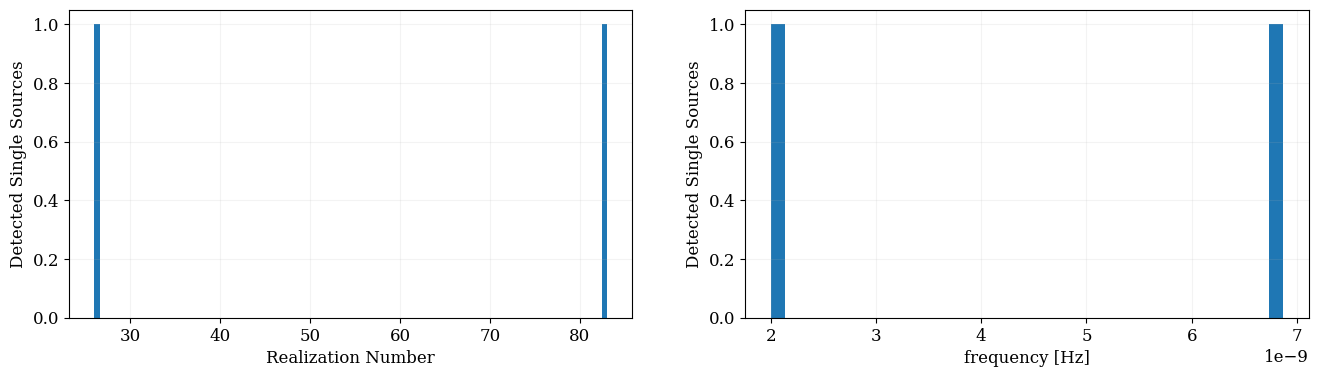

In [72]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
axs[0].hist(realization_number,bins=NUM_REALS)
axs[0].set_xlabel('Realization Number')
axs[0].set_ylabel('Detected Single Sources')
axs[1].hist(frequency_of_SMBHB,bins=NUM_FREQS)
axs[1].set_xlabel('frequency [Hz]')
axs[1].set_ylabel('Detected Single Sources')
print(f'There is a {100*success1/total1}% chance to detect a single source, with a mean number of detections of {np.mean(c1)}.')
plt.savefig('Figures/Single_Sources_Data',bbox_inches='tight')